# 7.0-model-comparison

## Imports

In [43]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from recruit_restaurant_visitor_forecasting.config.feature_names import agg_exp_col
from recruit_restaurant_visitor_forecasting.config.features import (
    TOTAL_RES_COL
)
from recruit_restaurant_visitor_forecasting.config.config import (
    VISIT_DATE_COL, MODELS_DIR
)
from recruit_restaurant_visitor_forecasting.config.modeling import TEST_SIZE
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict
from recruit_restaurant_visitor_forecasting.utils import get_rmsle

In [55]:
BASELINE_PATH = MODELS_DIR / "baseline_model.pkl"
LGBM_PATH = MODELS_DIR / "lgbm_optuna_recursive_model.pkl"
ACTUAL = "actual"
BASELINE_NAME = "baseline"
LGBM_NAME = "lgbm"
FOLD_COL = "fold"
RMSLE_SUFFIX = "_rmsle"
ERROR_SUFFIX = "_error"

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)
X = features
y = labels
res_features = [agg_exp_col(TOTAL_RES_COL, i) for i in range(1, 40)]
X = X.drop(columns=res_features)

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-03-08 00:00:00
Test set dates: 2017-03-09 00:00:00 to 2017-04-22 00:00:00


In [4]:
baseline = joblib.load(BASELINE_PATH)
lgbm = joblib.load(LGBM_PATH)

## Comparison

In [5]:
baseline.fit(X_train, y_train)
y_test_baseline = baseline.predict(X_test)

In [6]:
y_test_lgbm, _ = recursive_predict(
    lgbm, X_test, X_train, y_train, update_reservations=False
)

Predicting recursively: 100%|██████████| 45/45 [01:14<00:00,  1.65s/it]


### Predictions

In [82]:
pred = pd.DataFrame({
    VISIT_DATE_COL: test_dates,
    ACTUAL: y_test,
    BASELINE_NAME: y_test_baseline,
    LGBM_NAME: y_test_lgbm
}).set_index(VISIT_DATE_COL)
pred_daily = pred.groupby(level=0).mean()

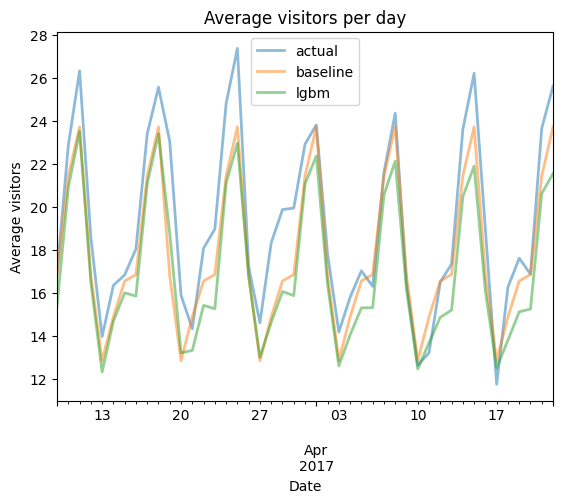

In [83]:
pred_daily.plot(linewidth=2, alpha=0.5)

plt.ylabel("Average visitors")
plt.xlabel("Date")
plt.title(f"Average visitors per day")
plt.show()

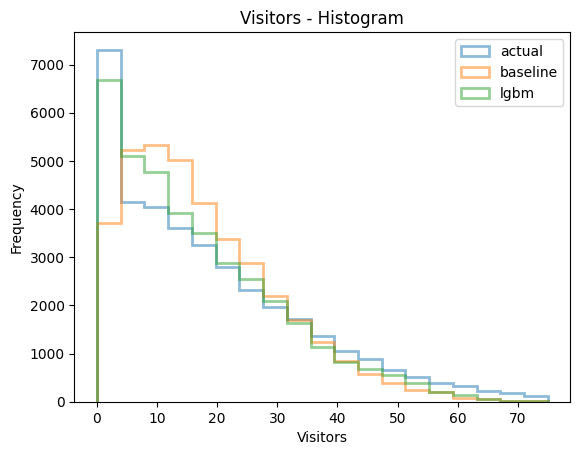

In [84]:
bins = np.linspace(pred.quantile(0.01).min(), pred.quantile(0.99).max(), 20)
pred.plot.hist(bins=bins, alpha=0.5, histtype="step", linewidth=2, xlabel="Visitors")
plt.title(f"Visitors - Histogram")
plt.show()

We see that the baseline tends to average out - far fewer near-zero values. Because of this, the average number of visitors per day may be higher than for lgbm. While it seems like a better prediction, the actual score isn't. Both models have fewer over-predictions and more under-predictions than the actual data.

### Errors

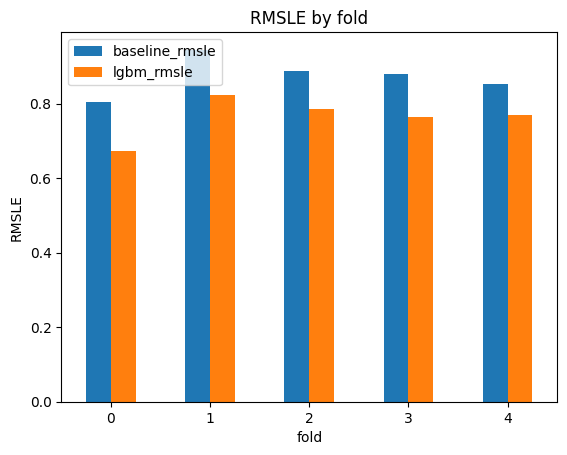

In [91]:
n_folds = 5

unique_dates = pred.index.unique().sort_values()
pred[FOLD_COL] = np.searchsorted(unique_dates, pred.index) * n_folds // len(unique_dates)

cols = [BASELINE_NAME, LGBM_NAME]
rmsle_df = pred.groupby(FOLD_COL).apply(
    lambda g: get_rmsle(g, cols, ACTUAL), include_groups=False
)
rmsle_df.plot.bar(rot=0, title="RMSLE by fold", ylabel="RMSLE")
plt.show()

In [95]:
pred.groupby(FOLD_COL).apply(
    lambda x: pd.Series({
        "min_date": x.index.min(),
        "max_date": x.index.max(),
    }),
    include_groups=False,
)

,min_date,max_date
fold,,
0,2017-03-09,2017-03-17
1,2017-03-18,2017-03-26
2,2017-03-27,2017-04-04
3,2017-04-05,2017-04-13
4,2017-04-14,2017-04-22


The difference between the predictions decreases slightly over time, but there is no such thing as the baseline score being better at any given fold.

In [96]:
errors = {col + ERROR_SUFFIX: pred[ACTUAL] - pred[col] for col in cols}
errors = pd.DataFrame(errors, index=pred.index)

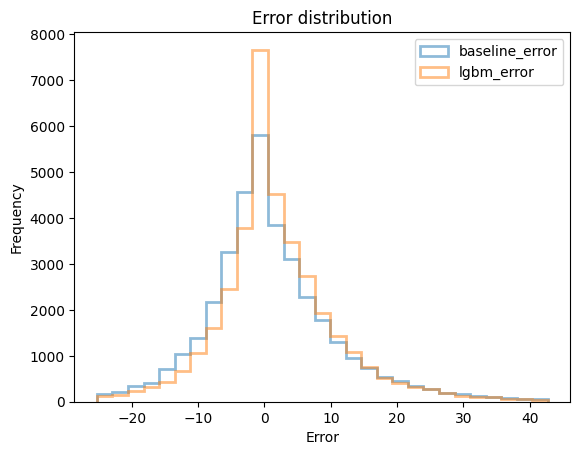

In [104]:
bins = np.linspace(errors.quantile(0.01).min(), errors.quantile(0.99).max(), 30)
errors.plot.hist(bins=bins, alpha=0.5, histtype="step", linewidth=2, xlabel="Error")
plt.title("Error distribution")
plt.show()

Both baseline and lgbm have a right-hand tail (often underpredicting), but the baseline's distribution appears more symmetrical near zero. lgbm, on the other hand, has more errors near zero, which is a better.